In [3]:
import numpy as np
import matplotlib.pyplot as plt

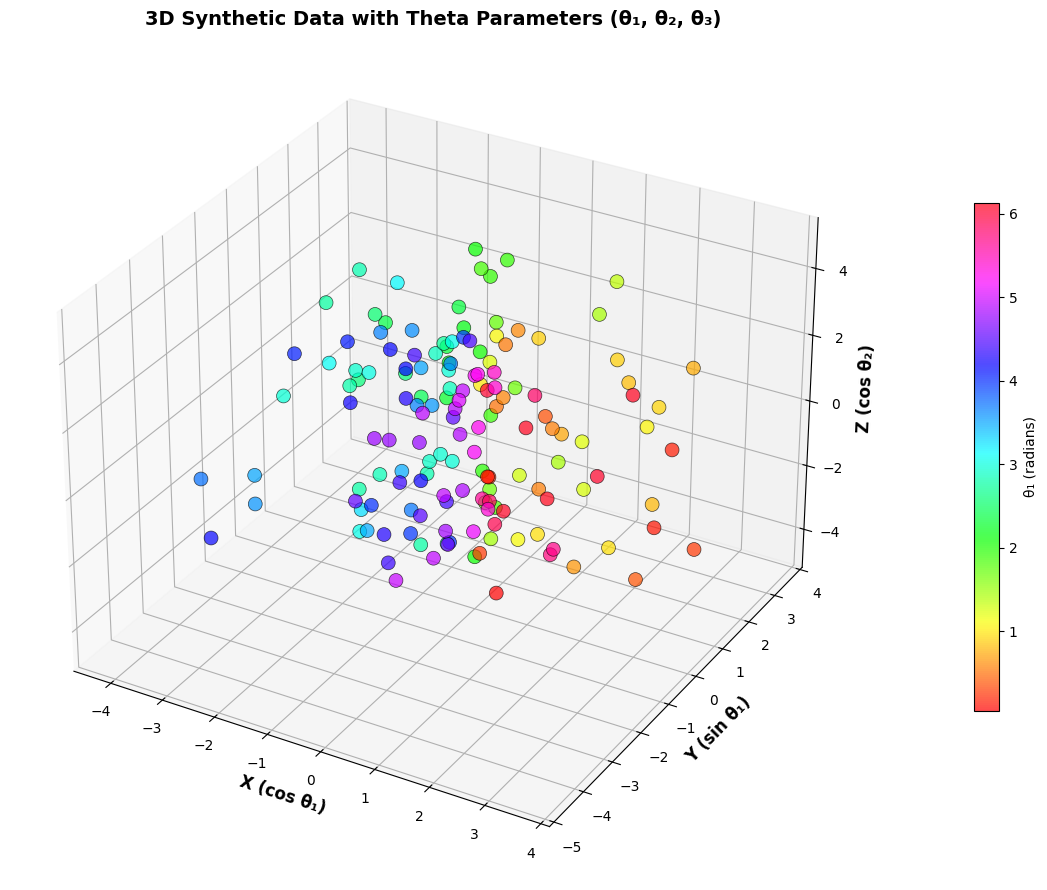

3D SYNTHETIC DATA SUMMARY
Number of points: 150
θ₁ (theta1) - Range: [0.046, 6.130] radians
θ₂ (theta2) - Range: [0.044, 3.118] radians
θ₃ (theta3) - Range: [-3.107, 3.136] radians
Radius - Range: [1.029, 4.982]


In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic 3D data with three theta parameters
rng = np.random.default_rng(seed=42)
num_points = 150

# Generate theta parameters (angles in radians)
theta1 = rng.uniform(0, 2*np.pi, num_points)  # 0 to 2π
theta2 = rng.uniform(0, np.pi, num_points)    # 0 to π
theta3 = rng.uniform(-np.pi, np.pi, num_points)  # -π to π

# Spherical to Cartesian conversion
radius = rng.uniform(1, 5, num_points)
x = radius * np.sin(theta2) * np.cos(theta1)
y = radius * np.sin(theta2) * np.sin(theta1)
z = radius * np.cos(theta2)

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(x, y, z, c=theta1, cmap='hsv', marker='o', s=100, alpha=0.7, edgecolors='k', linewidth=0.5)

ax.set_xlabel('X (cos θ₁)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (sin θ₁)', fontsize=12, fontweight='bold')
ax.set_zlabel('Z (cos θ₂)', fontsize=12, fontweight='bold')
ax.set_title('3D Synthetic Data with Theta Parameters (θ₁, θ₂, θ₃)', fontsize=14, fontweight='bold')

cbar = plt.colorbar(scatter, ax=ax, label='θ₁ (radians)', shrink=0.6, pad=0.1)
plt.tight_layout()
plt.show()

print("=" * 70)
print("3D SYNTHETIC DATA SUMMARY")
print("=" * 70)
print(f"Number of points: {num_points}")
print(f"θ₁ (theta1) - Range: [{theta1.min():.3f}, {theta1.max():.3f}] radians")
print(f"θ₂ (theta2) - Range: [{theta2.min():.3f}, {theta2.max():.3f}] radians")
print(f"θ₃ (theta3) - Range: [{theta3.min():.3f}, {theta3.max():.3f}] radians")
print(f"Radius - Range: [{radius.min():.3f}, {radius.max():.3f}]")
print("=" * 70)


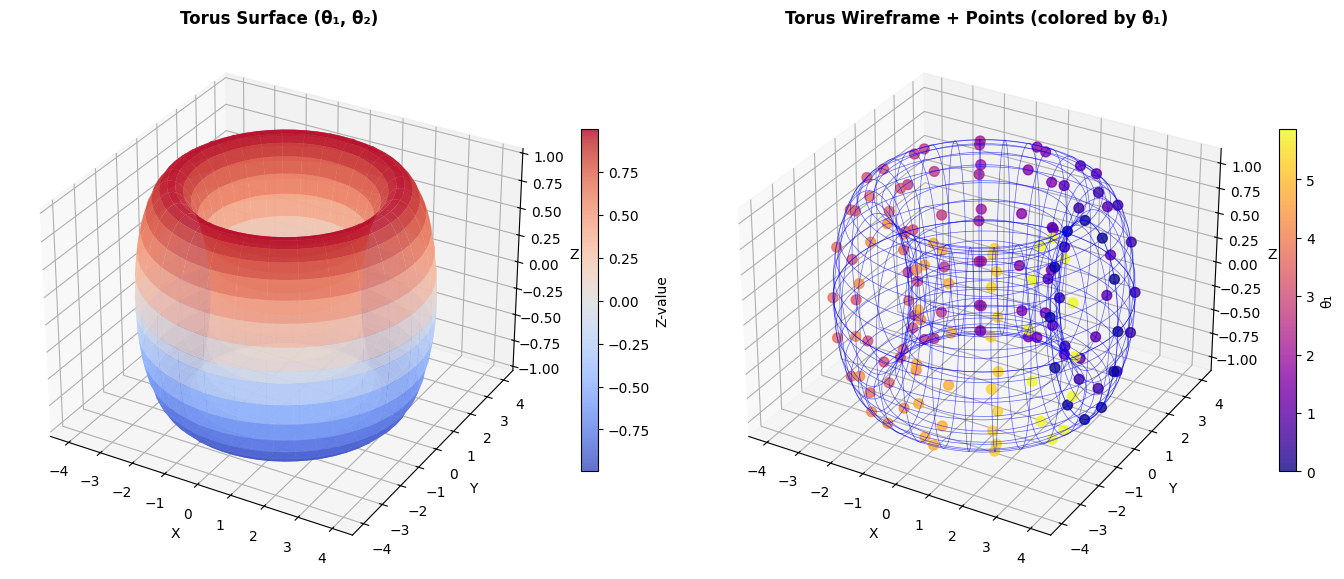


Torus Parameters:
Major radius (R): 3
Minor radius (r): 1
θ₁ points: 60, θ₂ points: 60
Total surface points: 3600


In [5]:
# Parametric Surface: Torus with theta1 and theta2

# Create a mesh grid
theta1_grid = np.linspace(0, 2*np.pi, 60)
theta2_grid = np.linspace(0, 2*np.pi, 60)
theta1_mesh, theta2_mesh = np.meshgrid(theta1_grid, theta2_grid)

# Torus parametric equations
R = 3      # Distance from center to tube center
r = 1      # Tube radius

x_torus = (R + r * np.cos(theta2_mesh)) * np.cos(theta1_mesh)
y_torus = (R + r * np.cos(theta2_mesh)) * np.sin(theta1_mesh)
z_torus = r * np.sin(theta2_mesh)

# Plot the torus
fig = plt.figure(figsize=(14, 6))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(x_torus, y_torus, z_torus, cmap='coolwarm', alpha=0.8, edgecolor='none')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Torus Surface (θ₁, θ₂)', fontsize=12, fontweight='bold')
plt.colorbar(surf, ax=ax1, label='Z-value', shrink=0.6)

# Wireframe with color
ax2 = fig.add_subplot(122, projection='3d')
wireframe = ax2.plot_wireframe(x_torus, y_torus, z_torus, color='blue', alpha=0.6, linewidth=0.5)
scatter_points = ax2.scatter(x_torus[::5, ::5], y_torus[::5, ::5], z_torus[::5, ::5], 
                             c=theta1_mesh[::5, ::5], cmap='plasma', s=50, alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Torus Wireframe + Points (colored by θ₁)', fontsize=12, fontweight='bold')
plt.colorbar(scatter_points, ax=ax2, label='θ₁', shrink=0.6)

plt.tight_layout()
plt.show()

print("\nTorus Parameters:")
print(f"Major radius (R): {R}")
print(f"Minor radius (r): {r}")
print(f"θ₁ points: {len(theta1_grid)}, θ₂ points: {len(theta2_grid)}")
print(f"Total surface points: {len(theta1_grid) * len(theta2_grid)}")


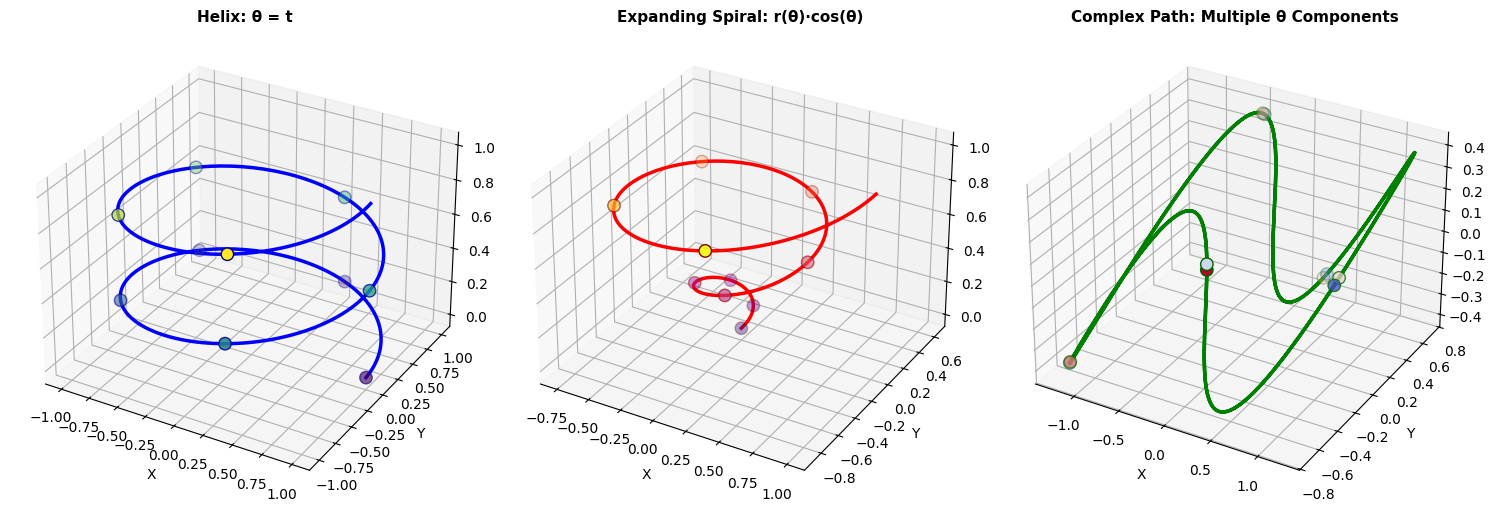


3D Parametric Curves Summary:
Parameter range: t ∈ [0, 12.57]
Points per curve: 300

Curve Types:
  1. Helix: x=cos(θ), y=sin(θ), z=θ/(4π)
  2. Spiral: x=r(θ)cos(θ), y=r(θ)sin(θ), z=θ/(4π)
  3. Complex: Uses three theta-like parameters with frequency modulation


In [6]:
# 3D Parametric Curves with Multiple Theta Parameters

t = np.linspace(0, 4*np.pi, 300)

fig = plt.figure(figsize=(15, 5))

# Helix curve
ax1 = fig.add_subplot(131, projection='3d')
x_helix = np.cos(t)
y_helix = np.sin(t)
z_helix = t / (4*np.pi)
line1 = ax1.plot(x_helix, y_helix, z_helix, 'b-', linewidth=2.5)
scatter1 = ax1.scatter(x_helix[::30], y_helix[::30], z_helix[::30], c=t[::30], cmap='viridis', s=80, edgecolor='darkblue')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Helix: θ = t', fontsize=11, fontweight='bold')

# Expanding spiral
ax2 = fig.add_subplot(132, projection='3d')
radius_spiral = t / (4*np.pi)
x_spiral = radius_spiral * np.cos(t)
y_spiral = radius_spiral * np.sin(t)
z_spiral = t / (4*np.pi)
line2 = ax2.plot(x_spiral, y_spiral, z_spiral, 'r-', linewidth=2.5)
scatter2 = ax2.scatter(x_spiral[::30], y_spiral[::30], z_spiral[::30], c=t[::30], cmap='plasma', s=80, edgecolor='darkred')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Expanding Spiral: r(θ)·cos(θ)', fontsize=11, fontweight='bold')

# Complex 3D path with three theta-like parameters
ax3 = fig.add_subplot(133, projection='3d')
x_complex = np.cos(t) * (1 + 0.5*np.sin(2*t))
y_complex = np.sin(t) * (1 + 0.5*np.cos(2*t))
z_complex = 0.4 * np.sin(3*t)
line3 = ax3.plot(x_complex, y_complex, z_complex, 'g-', linewidth=2.5)
scatter3 = ax3.scatter(x_complex[::30], y_complex[::30], z_complex[::30], c=t[::30], cmap='coolwarm', s=80, edgecolor='darkgreen')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('Complex Path: Multiple θ Components', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n3D Parametric Curves Summary:")
print(f"Parameter range: t ∈ [0, {t.max():.2f}]")
print(f"Points per curve: {len(t)}")
print("\nCurve Types:")
print("  1. Helix: x=cos(θ), y=sin(θ), z=θ/(4π)")
print("  2. Spiral: x=r(θ)cos(θ), y=r(θ)sin(θ), z=θ/(4π)")
print("  3. Complex: Uses three theta-like parameters with frequency modulation")


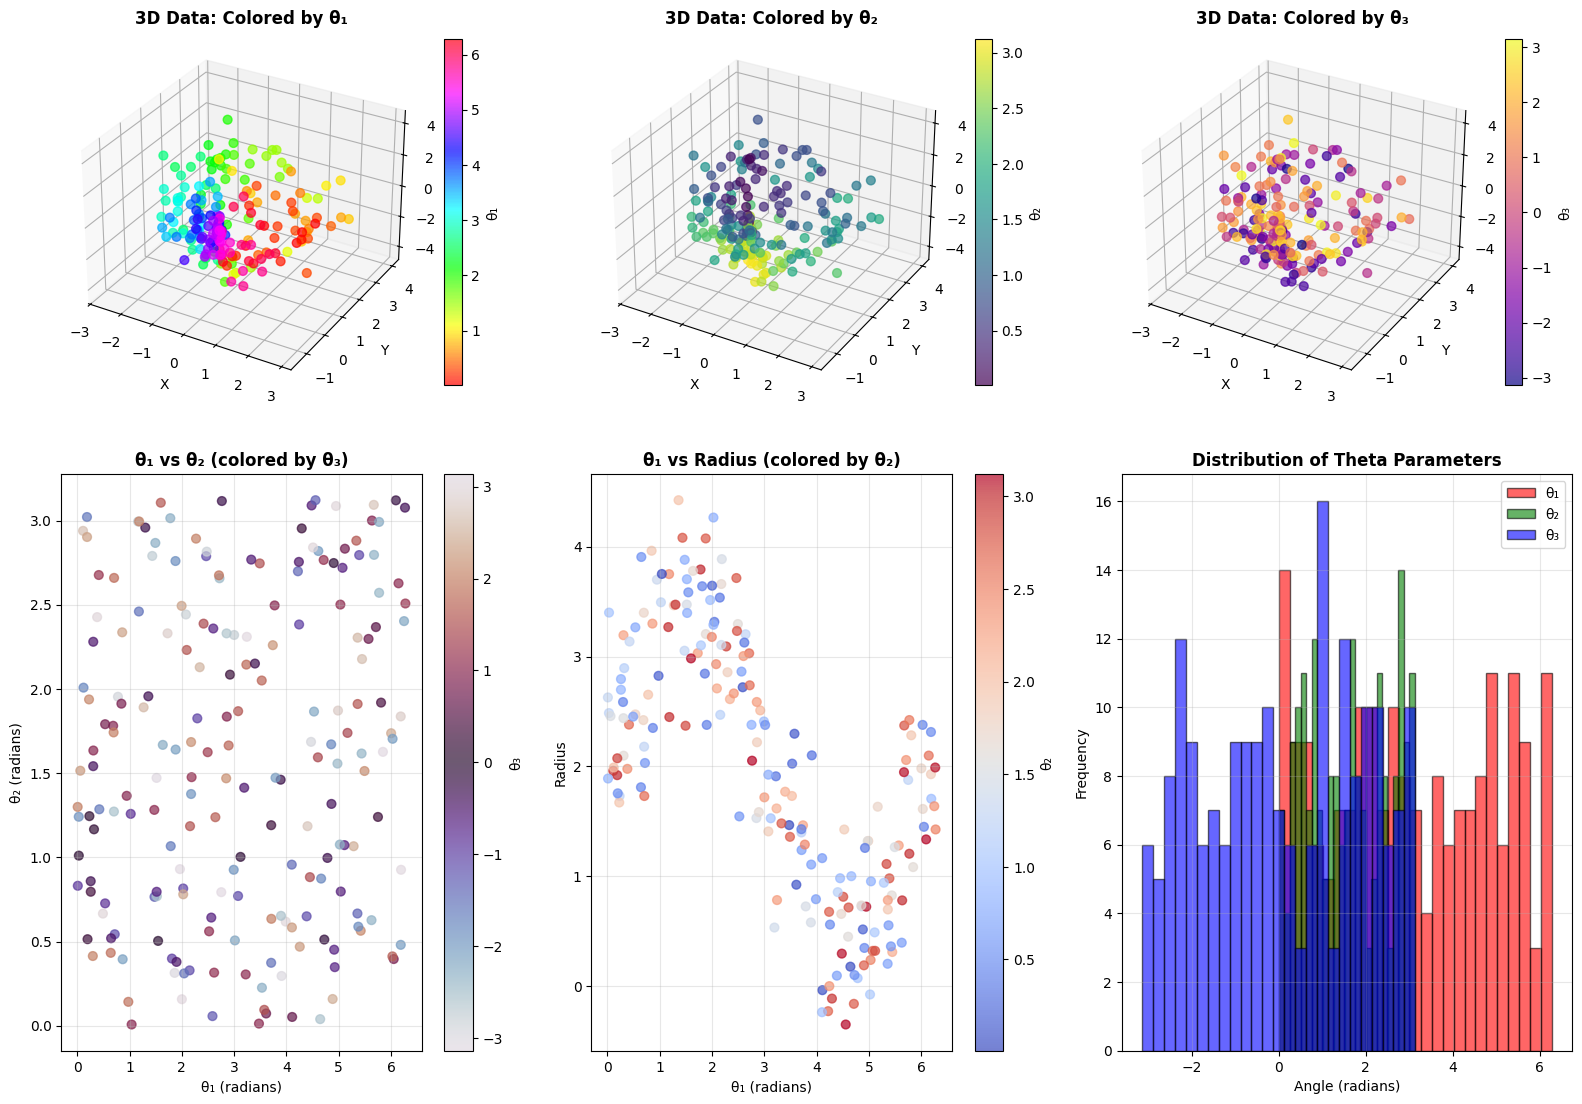


COMPREHENSIVE 3D DATA STATISTICS

Total data points: 200

θ₁ (theta1) - Azimuthal angle:
  Mean: 3.0765 rad, Std: 1.8852 rad
  Min: 0.0077 rad, Max: 6.2753 rad

θ₂ (theta2) - Polar angle:
  Mean: 1.5968 rad, Std: 0.9287 rad
  Min: 0.0073 rad, Max: 3.1208 rad

θ₃ (theta3) - Rotation angle:
  Mean: 0.0924 rad, Std: 1.8106 rad
  Min: -3.1383 rad, Max: 3.1380 rad

Radius:
  Mean: 1.9807, Std: 1.1525
  Min: -0.3484, Max: 4.4231

Cartesian Coordinates:
  X range: [-2.6565, 2.8782]
  Y range: [-1.4459, 4.0072]
  Z range: [-4.2589, 4.1669]


In [7]:
# Comprehensive 3D Data with All Theta Parameters

# Generate comprehensive synthetic dataset
n = 200
theta1_data = rng.uniform(0, 2*np.pi, n)
theta2_data = rng.uniform(0, np.pi, n)
theta3_data = rng.uniform(-np.pi, np.pi, n)
radius_data = 2 + 1.5*np.sin(theta1_data) + 0.5*rng.standard_normal(n)

# Convert to Cartesian
x_cart = radius_data * np.sin(theta2_data) * np.cos(theta1_data)
y_cart = radius_data * np.sin(theta2_data) * np.sin(theta1_data)
z_cart = radius_data * np.cos(theta2_data) + 0.5*np.sin(theta3_data)

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))

# 3D scatter colored by theta1
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
scatter1 = ax1.scatter(x_cart, y_cart, z_cart, c=theta1_data, cmap='hsv', s=40, alpha=0.7)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('3D Data: Colored by θ₁', fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='θ₁', shrink=0.6)

# 3D scatter colored by theta2
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
scatter2 = ax2.scatter(x_cart, y_cart, z_cart, c=theta2_data, cmap='viridis', s=40, alpha=0.7)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('3D Data: Colored by θ₂', fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='θ₂', shrink=0.6)

# 3D scatter colored by theta3
ax3 = fig.add_subplot(2, 3, 3, projection='3d')
scatter3 = ax3.scatter(x_cart, y_cart, z_cart, c=theta3_data, cmap='plasma', s=40, alpha=0.7)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('3D Data: Colored by θ₃', fontweight='bold')
plt.colorbar(scatter3, ax=ax3, label='θ₃', shrink=0.6)

# 2D projections
ax4 = fig.add_subplot(2, 3, 4)
scatter4 = ax4.scatter(theta1_data, theta2_data, c=theta3_data, cmap='twilight', s=40, alpha=0.7)
ax4.set_xlabel('θ₁ (radians)')
ax4.set_ylabel('θ₂ (radians)')
ax4.set_title('θ₁ vs θ₂ (colored by θ₃)', fontweight='bold')
plt.colorbar(scatter4, ax=ax4, label='θ₃')
ax4.grid(True, alpha=0.3)

# Radius vs theta1
ax5 = fig.add_subplot(2, 3, 5)
scatter5 = ax5.scatter(theta1_data, radius_data, c=theta2_data, cmap='coolwarm', s=40, alpha=0.7)
ax5.set_xlabel('θ₁ (radians)')
ax5.set_ylabel('Radius')
ax5.set_title('θ₁ vs Radius (colored by θ₂)', fontweight='bold')
plt.colorbar(scatter5, ax=ax5, label='θ₂')
ax5.grid(True, alpha=0.3)

# Distribution histograms
ax6 = fig.add_subplot(2, 3, 6)
ax6.hist(theta1_data, bins=25, alpha=0.6, label='θ₁', color='red', edgecolor='black')
ax6.hist(theta2_data, bins=25, alpha=0.6, label='θ₂', color='green', edgecolor='black')
ax6.hist(theta3_data, bins=25, alpha=0.6, label='θ₃', color='blue', edgecolor='black')
ax6.set_xlabel('Angle (radians)')
ax6.set_ylabel('Frequency')
ax6.set_title('Distribution of Theta Parameters', fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print data statistics
print("\n" + "="*80)
print("COMPREHENSIVE 3D DATA STATISTICS")
print("="*80)
print(f"\nTotal data points: {n}")
print(f"\nθ₁ (theta1) - Azimuthal angle:")
print(f"  Mean: {np.mean(theta1_data):.4f} rad, Std: {np.std(theta1_data):.4f} rad")
print(f"  Min: {np.min(theta1_data):.4f} rad, Max: {np.max(theta1_data):.4f} rad")

print(f"\nθ₂ (theta2) - Polar angle:")
print(f"  Mean: {np.mean(theta2_data):.4f} rad, Std: {np.std(theta2_data):.4f} rad")
print(f"  Min: {np.min(theta2_data):.4f} rad, Max: {np.max(theta2_data):.4f} rad")

print(f"\nθ₃ (theta3) - Rotation angle:")
print(f"  Mean: {np.mean(theta3_data):.4f} rad, Std: {np.std(theta3_data):.4f} rad")
print(f"  Min: {np.min(theta3_data):.4f} rad, Max: {np.max(theta3_data):.4f} rad")

print(f"\nRadius:")
print(f"  Mean: {np.mean(radius_data):.4f}, Std: {np.std(radius_data):.4f}")
print(f"  Min: {np.min(radius_data):.4f}, Max: {np.max(radius_data):.4f}")

print(f"\nCartesian Coordinates:")
print(f"  X range: [{np.min(x_cart):.4f}, {np.max(x_cart):.4f}]")
print(f"  Y range: [{np.min(y_cart):.4f}, {np.max(y_cart):.4f}]")
print(f"  Z range: [{np.min(z_cart):.4f}, {np.max(z_cart):.4f}]")
print("="*80)
